# 🍇 Sensitivity analysis for grapevine 🍇

This script is designed to perform sensitivity analysis on a simulation model using the calisim library. Sensitivity analysis helps identify how variations in input parameters affect the output of a model. The script sets up the input parameters, collects input-output samples, and uses sensitivity analysis methods (e.g., **Sobol indices** and **F-value**) to analyse the model's behavior.

In [1]:
import os
import sys
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image, clear_output

from calisim.data_model import (
    DistributionModel,
    ParameterDataType,
    ParameterSpecification,
)
from calisim.sensitivity import (
    SensitivityAnalysisMethod,
    SensitivityAnalysisMethodModel,
)
from calisim.utils import get_examples_outdir


/tmp/ipykernel_50729/3425801241.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Define output directory
vine_type = "spur" # e.g., "spur", "cane" or "all"
outdir = "outdir/spur" # e.g., "outdir/spur", "outdir/cane" or "outdir"
os.makedirs(outdir, exist_ok=True)
SAVE_COMBINED_CSV = False # Save the new combine_all_daily_average_new, spur_df or cane_df
APPLY_FILTER = True
filter = {
    "Tmax": [25, 30],
    "Tmin": [15, 20],
    "cca": [400, 650, 900, 1200],
    "inputPAR": [400, 600, 1000, 1200],
    "ENDING_LEAF_NUMBER": [3, 6, 9, 12]
}


## Key Components and Setup ⚙️

### 1. Define Input Parameters 👷
Defines the input variables for the sensitivity analysis. These variables represent the **factors** that influence the simulation model's output.

In [3]:
input_cols = [
    "Ta",  # Ambient air temperature around the plant
    "cca",  # Co2 concentration in air
    "totalFruitNumber",  # Total number of fruits present on the plant
    "incomingRadiation",  # Rate of solar radiation received per unit area
    "leafArea",  # Total surface area of leaves on the plant
    
]
new_input_cols = ["dayTemperature", "nightTemperature"] # 14 hours daytime start from 7 AM to 9 PM, the remaining is night time
new_input_cols = [] # Not use "dayTemperature" and "nightTemperature" now


### 2. Folders and Data Path
These paths are used to collect input-output samples for the analysis.

In [4]:
if vine_type == "spur":
    folders = ["spur_70", "spur_50", "spur_90", "spur_110"] # The subdirectories containing simulation data 
elif vine_type == "cane":
    folders = ["cane_20", "cane_30", "cane_40", "cane_50"]
else:
    folders = ["spur_70", "spur_50", "spur_90", "spur_110", "cane_20", "cane_30", "cane_40", "cane_50"] 

base_path = "/output/FruitCropXL/HGU-sim/" # The root directory for the data


### 3. Define Model Output Targets 👷
Specifies the simulation outputs of interest (targets) for sensitivity analysis. These include plant-level and fruit-level variables.

In [5]:
plant_targets = [
    "biomassPlant",
    "biomassFruit",
    "biomassInternode",
    "internodeNSC",
    "fraction_fruitUnloading",
    "fraction_structuralRootUnloading",
    "fraction_internodeUnloading",
    # "fraction_leafUnloading",
    # "fraction_fineRootUnloading",
    # "fraction_flowerUnloading",
    # "fraction_petioleUnloading",
    "phloemSugarConcentration",
    "harvest_index"
]

fruit_targets = ["meanFruitDW", "meanFruitSc"]
targets = plant_targets + fruit_targets


### 4. Collect input-output samples from a set of folders and subfolders containing simulation data. 
It processes CSV files to extract input features (X_all) and output targets (Y_all) for sensitivity analysis:

In [6]:
def extract_factors(folder_str):
    parts = folder_str.split('_')
    vine_type = parts[1]  # e.g., 'spur' or 'cane'
    return pd.Series([vine_type], index=['vineType'])

def summarise_all_days(group):
    first = group.iloc[0]
    last = group.iloc[-1]
    delta_days = last["dayOfYear"] - first["dayOfYear"]

    # Skip if first dayOfYear is 0
    if first["dayOfYear"] == 0:
        print("Removed (first dayOfYear is 0):", group.name)
        return None

    # Skip if last dayOfYear is less than 70
    if last["dayOfYear"] < 70:
        print("Removed (last dayOfYear < 70):", group.name)
        return None

    # Skip if no time difference
    if delta_days == 0:
        print("Removed (no time difference):", group.name)
        return None

    result_dict = {}

    for col in targets:
        if col in ["biomassPlant", "biomassFruit", "biomassInternode", "internodeNSC"]:
            initial_value = first[col]
            final_value = last[col]
            if pd.isna(initial_value) or initial_value == 0:
                print(f"Removed ({col} initial is NaN or 0):", group.name)
                return None
            pct_increase = (final_value - initial_value) / initial_value * 100
            result_dict[col] = pct_increase
            result_dict[f"{col}_final"] = final_value
        elif col in ["fraction_fruitUnloading", "fraction_structuralRootUnloading", "fraction_internodeUnloading", "phloemSugarConcentration"]:
            result_dict[col] = group[col].mean()
        elif col in ["harvest_index", "meanFruitSc", "meanFruitDW"]:
            result_dict[col] = group.iloc[-1][col]
            
    # Add means of input columns
    for col in input_cols + ["Tmax", "Tmin"]:
        mean_val = group[col].mean()
        result_dict[col] = mean_val

    result_dict["ENDING_LEAF_NUMBER"] = group["ENDING_LEAF_NUMBER"].iloc[0]
    result_dict["vineType"] = group["vineType"].iloc[0]
    
    return pd.Series(result_dict)


combine_all_daily_average = []
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    subfolders = [d for d in glob(os.path.join(folder_path, "*")) if os.path.isdir(d)]

    for subfolder in subfolders:
        # Find plant-level and mean-fruit CSVs
        plant_csv_files = glob(os.path.join(subfolder, "plant-level-*.csv"))
        fruit_csv_files = glob(os.path.join(subfolder, "mean-fruit-*.csv"))

        if not plant_csv_files or not fruit_csv_files:
            continue  # Skip if missing files

        df_plant = pd.read_csv(plant_csv_files[0])
        df_fruit = pd.read_csv(fruit_csv_files[0])

        # Compute day and night temperature
        day_temp = df_plant[df_plant["hourOfDay"].between(7, 20)]["Ta"].mean()
        night_temp = df_plant[~df_plant["hourOfDay"].between(7, 20)]["Ta"].mean()
        # Compute harvest index
        df_plant["harvest_index"] = df_plant["biomassFruit"] / df_plant["biomassPlant"]

        if np.isnan(day_temp) or np.isnan(night_temp):
            continue  # Skip this folder due to missing daytime or nighttime data

        # Combine all daily-averaged rows across folders
        df_fruit_cleaned = df_fruit[df_fruit.columns.difference(df_plant.columns)]
        combined_df = df_plant.join(df_fruit_cleaned)
        combined_df['year'] = combined_df['year'].astype("category")
        combined_df.drop(columns='hourOfDay', inplace=True)
        combined_df.drop(columns='timestamp', inplace=True)
        daily_avg_df = combined_df.groupby("dayOfYear", as_index=False).mean(numeric_only=True)
        daily_avg_df['dayTemperature'] = day_temp
        daily_avg_df['nightTemperature'] = night_temp
        daily_avg_df['folder'] = os.path.basename(subfolder)
        cols = ['folder'] + [col for col in daily_avg_df.columns if col != 'folder']
        daily_avg_df = daily_avg_df[cols]
        combine_all_daily_average.append(daily_avg_df)


big_df = pd.concat(combine_all_daily_average, axis=0, ignore_index=True)
# Merge field-space_total csv with big_df
field_space_total_df = pd.read_csv("field-space_total.csv")
big_df['uuid'] = big_df['folder'].str.extract(
r'([0-9a-f]{8}_[0-9a-f]{4}_[0-9a-f]{4}_[0-9a-f]{4}_[0-9a-f]{12})'
)
big_df['uuid'] = big_df['uuid'].str.replace('_', '-', regex=False)
big_df = field_space_total_df.merge(big_df, on='uuid', how='right')
big_df = big_df.drop(columns=['cca_x'])
big_df = big_df.rename(columns={'cca_y': 'cca'})

big_df[['vineType']] = big_df['folder'].apply(extract_factors)
spur_df = big_df[big_df['vineType'] == 'spur']
print("spur_df.size:", spur_df.size)
cane_df = big_df[big_df['vineType'] == 'cane']
print("cane_df.size:", cane_df.size)
if SAVE_COMBINED_CSV:
    if vine_type == "spur":
        spur_df.to_csv(f"{outdir}/spur_df.csv", index=False)
    elif vine_type == "cane":
        cane_df.to_csv(f"{outdir}/cane_df.csv", index=False)
    else:
        big_df.to_csv("outdir/combine_all_daily_average_new.csv", index=False)
        big_df.to_csv("/output/FruitCropXL/combine_all_daily_average_new.csv", index=False)




spur_df.size: 5509742
cane_df.size: 0


In [7]:
# ============================================================
# Reconstruct missing metadata for cane_40/cane_50 (320/400 crop load),
# which are absent from field_space_total_df. Tmax, Tmin, inputPAR, and ENDING_LEAF_NUMBER
# come back as NaN for these uuids without this step.
# ============================================================

if vine_type == "cane":
    cane_high = cane_df[cane_df['totalFruitNumber'].isin([320, 400])].copy()
    
    # Tmax / Tmin: inferred from realized day/night temperature
    # Verified: clean, well-separated clusters (histogram check), balanced
    # 2x2 crosstab (127-129 uuids per cell) matching the known experimental design.
    def infer_tmax(day_temp):
        return 25 if day_temp < 26 else 30
    
    def infer_tmin(night_temp):
        return 15 if night_temp < 19 else 20
    
    cane_high['Tmax'] = cane_high['dayTemperature'].apply(infer_tmax)
    cane_high['Tmin'] = cane_high['nightTemperature'].apply(infer_tmin)
    
    # inputPAR: inferred from realized incomingRadiation, per-uuid mean
    # Verified: four clean clusters (~275/400/700/830), consistent ~69% ratio
    # to each setpoint (canopy attenuation), balanced counts (124-131 per level).
    def infer_inputpar(mean_rad):
        if mean_rad < 340:
            return 400
        elif mean_rad < 550:
            return 600
        elif mean_rad < 765:
            return 1000
        else:
            return 1200
    
    uuid_par = cane_high.groupby('uuid')['incomingRadiation'].mean().apply(infer_inputpar)
    cane_high['inputPAR'] = cane_high['uuid'].map(uuid_par)
    
    # ENDING_LEAF_NUMBER: exact conversion, verified against known-good data
    # final leafNumber = 8 x ENDING_LEAF_NUMBER, zero variance across all 501
    # known-good (160/240) simulations. This is a confirmed formula, not a
    # statistical inference like the three variables above.
    final_leaf_high = (cane_high.sort_values(['uuid', 'dayOfYear'])
                        .groupby('uuid')['leafNumber'].last() / 8)
    cane_high['ENDING_LEAF_NUMBER'] = cane_high['uuid'].map(final_leaf_high)
    
    cane_high_fix = cane_high  # reconstructed 320/400 rows, ready to merge
    
    # Rebuild the complete cane dataset
    cane_known_good = cane_df[cane_df['totalFruitNumber'].isin([160, 240])].copy()
    cane_df_complete = pd.concat([cane_known_good, cane_high_fix], ignore_index=True)
    
    print("Per crop-load uuid counts:")
    print(cane_df_complete.groupby('totalFruitNumber')['uuid'].nunique())
    
    # Final verification: confirm all four crop-load levels survive every filter
    print("\nFilter trace:")
    test_df = cane_df_complete.copy()
    for col, values in filter.items():
        before = sorted(test_df['totalFruitNumber'].unique())
        test_df = test_df[test_df[col].isin(values)]
        after = sorted(test_df['totalFruitNumber'].unique())
        print(f"  After '{col}': {before} -> {after}")

In [8]:
# old_big_df = pd.read_csv("outdir/combine_all_daily_average.csv")
# old_big_df[['vineType']] = old_big_df['folder'].apply(extract_factors)

if vine_type == "spur":
    #old_spur_df = old_big_df[old_big_df['vineType'] == 'spur']
    #combined_df = pd.concat([spur_df, old_spur_df], ignore_index=True, sort=False)
    combined_df = spur_df
elif vine_type == "cane":
    #old_cane_df = old_big_df[old_big_df['vineType'] == 'cane']
    #combined_df = pd.concat([cane_df, old_cane_df], ignore_index=True, sort=False)
    combined_df = cane_df_complete
else:
    #combined_df = pd.concat([big_df, old_big_df], ignore_index=True, sort=False)
    combined_df = big_df
    
if APPLY_FILTER:
    for col, values in filter.items():
        combined_df = combined_df[combined_df[col].isin(values)]
        
combined_df.to_csv(f"{outdir}/daily_timeseries_with_treatment.csv", index=False)

df_sorted = combined_df.sort_values(by=["uuid", "dayOfYear"])
per_simulation_df = df_sorted.groupby("uuid").apply(summarise_all_days)
per_simulation_df = per_simulation_df.dropna(how='all')  # Remove rows where all values are NaN
per_simulation_df = per_simulation_df.reset_index()

per_simulation_df.to_csv(f"{outdir}/per_simulation_df_with_treatment.csv", index=False)
print(sorted(per_simulation_df['totalFruitNumber'].unique()))

if APPLY_FILTER and SAVE_COMBINED_CSV:
    per_simulation_df.to_csv(f"{outdir}/resampled_per_simulation_df.csv", index=False)
elif SAVE_COMBINED_CSV:
    per_simulation_df.to_csv(f"{outdir}/per_simulation_df.csv", index=False)
else:
    pass
X_all = per_simulation_df[input_cols].values.tolist()   # Inputs as list of lists
Y_all = per_simulation_df[targets].values.tolist() 


Removed (last dayOfYear < 70): 09167b98-af3c-42ec-a969-45cc77c6d636
Removed (last dayOfYear < 70): 0e945ba9-67e0-4b03-b5ab-1030250fb93d
Removed (last dayOfYear < 70): 128749fe-d8b7-4557-85f0-06795523afcd
Removed (last dayOfYear < 70): 143f57a5-5867-4933-8bbf-871a47e9a795
Removed (last dayOfYear < 70): 1727ddc3-c989-4248-ad0c-95774a55600e
Removed (last dayOfYear < 70): 17ec3098-67ed-4d43-9c3b-fa4569e20ed6
Removed (last dayOfYear < 70): 1ddc4196-4861-44b9-96bd-463e521b0736
Removed (last dayOfYear < 70): 1e5e2957-e836-41b8-a99d-d259fe9f545c
Removed (last dayOfYear < 70): 1f36f8b7-4d1b-4fd4-9163-e713184e122d
Removed (last dayOfYear < 70): 1f7c3e3a-8aed-46b1-8ad4-cb52a8ed81cc
Removed (last dayOfYear < 70): 20635f0d-7ea2-4f0c-8533-131718daafe7
Removed (last dayOfYear < 70): 208158be-8806-4874-a912-16a3d37d4097
Removed (last dayOfYear < 70): 21a75fb1-3725-4354-ae31-19052e3e1c0a
Removed (last dayOfYear < 70): 21e5b609-377b-435e-a873-c0aac2381800
Removed (last dayOfYear < 70): 259d9177-09aa-45d

/tmp/ipykernel_50729/3041495706.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_simulation_df = df_sorted.groupby("uuid").apply(summarise_all_days)


In [9]:
X = np.array(X_all)
Y = np.array(Y_all)
print("X:", X.shape)
print("Y:", Y.shape)

pct_increase_Y = {
    f"{target}_pct_increase_Y": Y[:, i]
    for i, target in enumerate(plant_targets + fruit_targets)
}


X: (943, 5)
Y: (943, 11)


### 5. Defines the input parameter space for the sensitivity analysis (Sobol index). 
It specifies the parameters, their distributions, and their ranges based on the input data (X)

In [10]:
# all_input_cols = input_cols + new_input_cols

# parameter_spec = ParameterSpecification(
#     parameters=[
#         DistributionModel(
#             name=col,
#             distribution_name="uniform",
#             distribution_args=[X[:, i].min(), X[:, i].max()],
#             data_type=ParameterDataType.CONTINUOUS,
#         )
#         for i, col in enumerate(all_input_cols)
#     ]
# )


### 6.Run Sensitivity Analysis I (Sobol index) (NOT RELIABLE)
Executes the sensitivity analysis for each target, collecting the **first-order** and **total-order** Sobol indices for each input parameter, and storing the results.

- First-order Sobol index (Sᵢ):

Measures the **individual effect** of variable i on the output, ignoring interactions.

It's the fraction of output variance explained by changing input i alone.

Example: If S₁ = 0.6, then input 1 alone explains 60% of the output variance.

- Total-order Sobol index (Sᵢₜ):

Measures the total contribution of variable i, including: its **main effect**, and **all interactions with other inputs**.

Example: If S₁ₜ = 0.9, input 1 affects 90% of the variance **directly or through interactions**.

Likely Reasons Why chaos_sobol Was Less Reliable:
1. Model assumptions not satisfied or surrogate fit is poor: chaos_sobol relies on building a Polynomial Chaos Expansion (PCE) surrogate model. If the system is non-smooth, has discontinuities, or complex interactions not well approximated by low-order polynomials (even at order 4), the PCE can perform poorly. A poor surrogate leads to unreliable Sobol index estimates.
2. Limited number of samples: chaos_sobol is sample-hungry, especially as input dimensionality or polynomial order increases. If the number of simulations (n_samples) was not sufficient to fit the expansion accurately, the Sobol indices become noisy and unstable.
3. Input distribution assumptions: Polynomial chaos often assumes inputs follow standard distributions (e.g., uniform, normal). If inputs are non-standard or non-independent, that mismatch can affect the reliability of Sobol results unless corrected explicitly.

In [11]:
# # A placeholder function, which will be used to run the simulation and return results.
# def sensitivity_func(
#     parameters: dict, simulation_id: str, observed_data: np.ndarray | None, t: pd.Series
# ) -> float | list[float]:
#     pass

# results = []
# for target in targets:
#     specification = SensitivityAnalysisMethodModel(
#         X=X,
#         Y=pct_increase_Y[f"{target}_pct_increase_Y"],
#         experiment_name=f"openturns_sensitivity_analysis_{target}_pct_increase",
#         parameter_spec=parameter_spec,
#         outdir=outdir,
#         method="chaos_sobol",
#         order=4,
#         n_samples=X.shape[0],
#         output_labels=[target],
#         verbose=True,
#         batched=False,
#         figsize=(10, 5),
#     )

#     # Initialise and run the sensitivity analysis method
#     calibrator = SensitivityAnalysisMethod(
#         calibration_func=sensitivity_func,
#         specification=specification,
#         engine="openturns",
#     )

#     calibrator.specify().execute().analyze()

#     first_order = calibrator.implementation.first_order
#     total_order = calibrator.implementation.total_order

#     target_results = {"target": target}
#     for i, col in enumerate(all_input_cols):
#         target_results[f"{col}_first_order"] = first_order[i]
#         target_results[f"{col}_total_order"] = total_order[i]

#     results.append(target_results)


### 7. Visualise Results 
#### In a table format:

In [12]:
# results_df = pd.DataFrame(results)
# display(results_df)
# results_df.to_csv(f"{outdir}/sobol_index_sensitivity_analysis_results_with_inputs.csv", index=False)


#### Combine results into a graph:

In [13]:
# def plot_top_influences(df, targets, top_n=5):
#     ncols = 2
#     nrows = (len(targets) + ncols - 1) // ncols
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3.5 * nrows))
#     axes = axes.flatten()

#     for i, target in enumerate(targets):
#         row = df[df['target'] == target].T
#         row = row.drop(index='target')
#         row.columns = [target]

#         first_order_row = row[row.index.str.endswith('first_order')]
#         total_order_row = row[row.index.str.endswith('total_order')]

#         # Sort both rows and keep top N
#         first_order_row = first_order_row.sort_values(by=target, ascending=False).head(top_n)
#         total_order_row = total_order_row.sort_values(by=target, ascending=False).head(top_n)

#         # Clean input factor names
#         first_order_row.index = [idx.replace('_first_order', '') for idx in first_order_row.index]
#         total_order_row.index = [idx.replace('_total_order', '') for idx in total_order_row.index]
#         ax = axes[i]
#         first_order_plot = first_order_row.plot(kind="barh", ax=ax, color='blue', width=0.4, position=1, legend=False)
#         total_order_plot = total_order_row.plot(kind="barh", ax=ax, color='orange', width=0.4, position=0, legend=False)
#         for p in first_order_plot.patches:
#             ax.text(p.get_width() + 0.01, p.get_y() + p.get_height() / 2, f'{p.get_width():.4f}',
#                     va='center', fontsize=8)
#         for p in total_order_plot.patches:
#             ax.text(p.get_width() + 0.01, p.get_y() + p.get_height() / 2, f'{p.get_width():.4f}',
#                     va='center', fontsize=8)

#         ax.set_title(f"Top {top_n} Influences on {target}")
#         ax.set_xlabel("Sensitivity Index")

#         max_val = max(first_order_row[target].max(), total_order_row[target].max())
#         ax.set_xlim(0, max_val * 1.3)

#         ymin, ymax = ax.get_ylim()
#         ax.set_ylim(ymin - 0.3, ymax + 0.3)
        
#         ax.invert_yaxis()
#         ax.grid(axis='x', linestyle='--', alpha=0.6)

#         blue_patch = mpatches.Patch(color='blue', label='First Order')
#         orange_patch = mpatches.Patch(color='orange', label='Total Order')

#         ax.legend(handles=[blue_patch, orange_patch], loc='lower right')

#     plt.tight_layout()
#     plt.savefig(Path(outdir, f"sobol_index_final_result_{vine_type}.png"), dpi=300) 
#     plt.show()

# plot_top_influences(results_df, targets, top_n=5)


In [14]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
})

### 8. Run Sensitivity Analysis II (F-value)

All coefficients for harvest_index:
                                  Term   Coefficient
0                            Intercept  9.826900e-02
1                                  cca  2.124666e-05
2                     totalFruitNumber  3.041064e-03
3                             leafArea -3.722116e-01
4                                   Ta  2.055377e-03
5                    incomingRadiation  1.477396e-05
6                 cca:totalFruitNumber  1.697636e-08
7                         cca:leafArea -5.913860e-05
8                               cca:Ta -4.769823e-07
9                cca:incomingRadiation -2.291073e-09
10           totalFruitNumber:leafArea -5.445470e-03
11                 totalFruitNumber:Ta -1.449409e-06
12  totalFruitNumber:incomingRadiation  2.629396e-08
13                         leafArea:Ta -5.711493e-03
14          leafArea:incomingRadiation -1.009526e-06
15                Ta:incomingRadiation -5.675597e-07
Combined ANOVA Results for All Targets:


,Target,index,df,F,PR(>F),Partial_Eta2
5,biomassFruit,leafArea,1.0,7655.926971,0.000000e+00,0.891995
6,biomassFruit,Ta,1.0,209.857332,5.068436e-43,0.184594
7,biomassFruit,totalFruitNumber,1.0,195.662557,1.763605e-40,0.174284
8,biomassFruit,cca:incomingRadiation,1.0,168.573386,1.548136e-35,0.153868
9,biomassFruit,incomingRadiation,1.0,134.735661,3.517583e-29,0.126901
10,biomassInternode,leafArea,1.0,109248.905403,0.000000e+00,0.991586
11,biomassInternode,incomingRadiation,1.0,124.953723,2.651683e-27,0.118783
12,biomassInternode,leafArea:incomingRadiation,1.0,110.803420,1.487121e-24,0.106767
13,biomassInternode,leafArea:Ta,1.0,72.372258,7.086372e-17,0.072418
14,biomassInternode,totalFruitNumber,1.0,45.874554,2.236934e-11,0.047154


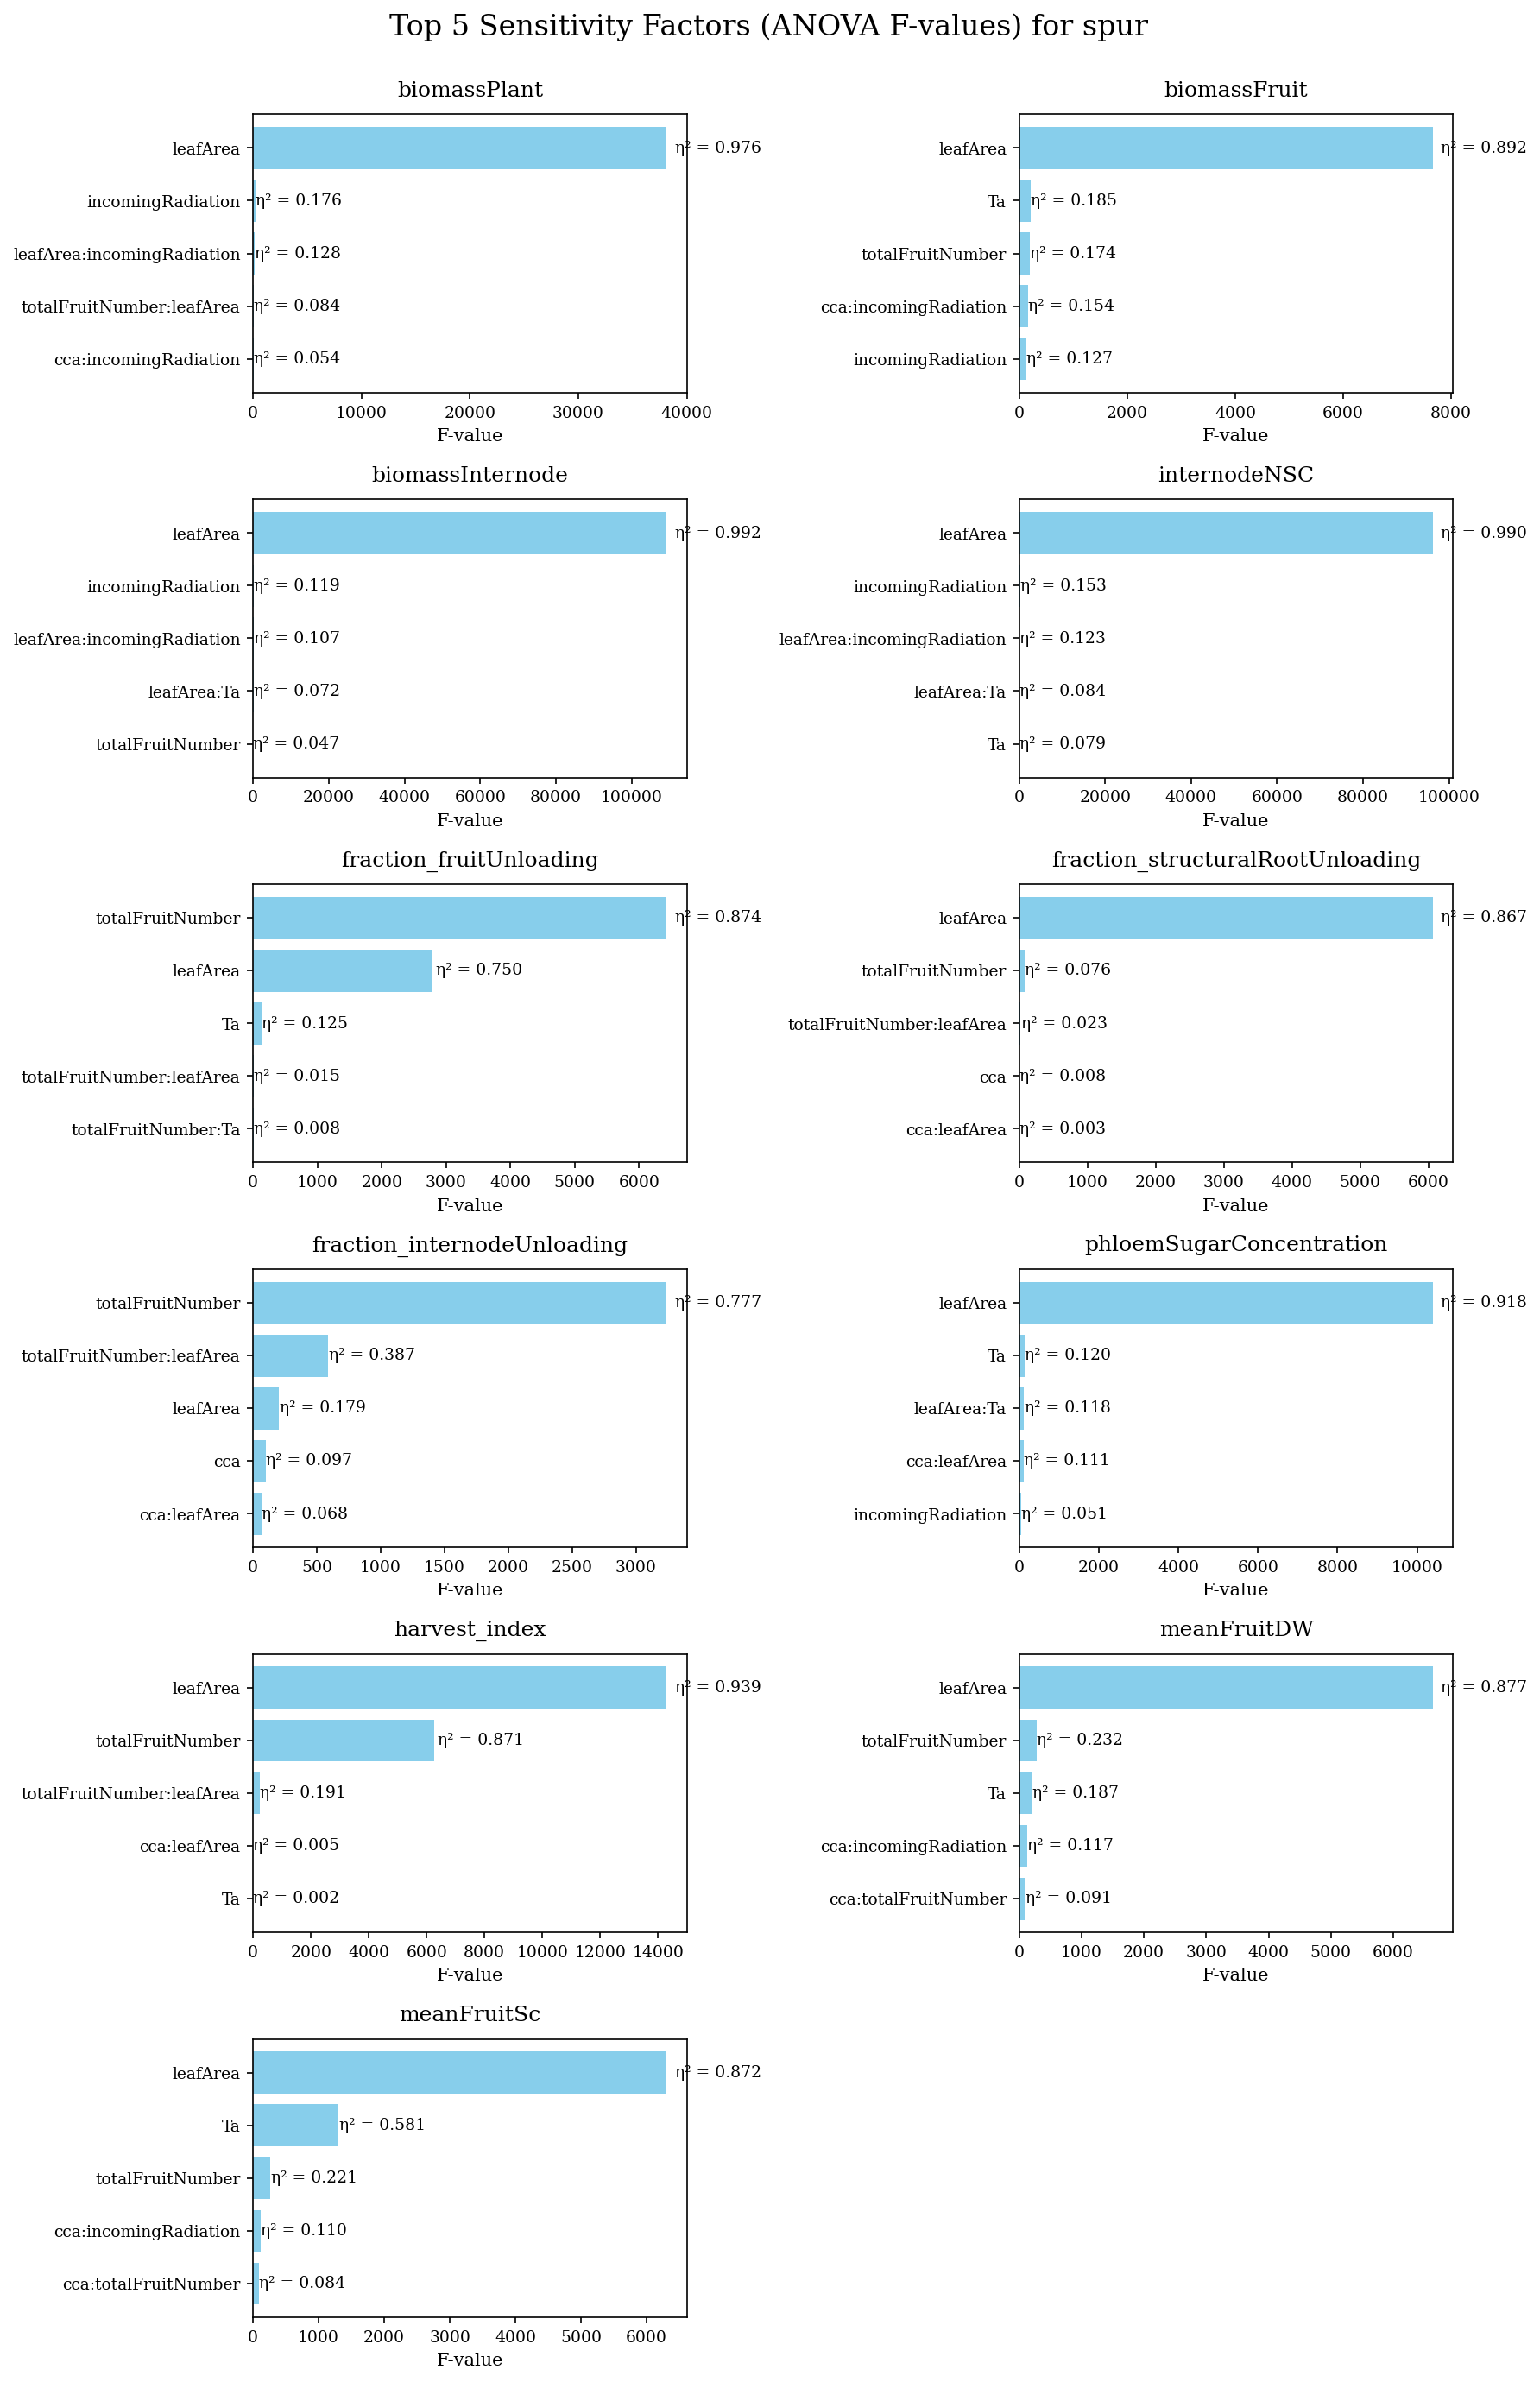

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

n_targets = len(targets)
ncols = 2
nrows = (n_targets + 1) // ncols
all_anova_tables = []
predictors = "(cca + totalFruitNumber + leafArea + Ta + incomingRadiation)**2"

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()

for i, target in enumerate(targets):
    ax = axes[i]
    formula = f"{target} ~ {predictors}"

    model = ols(formula, data=per_simulation_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2).reset_index()
    anova_table["Partial_Eta2"] = anova_table["F"] * anova_table["df"] / (anova_table["F"] * anova_table["df"] + model.df_resid)
    anova_table = anova_table[anova_table['index'] != 'Residual']
    anova_table["Target"] = target  # Label rows with the target variable
    all_anova_tables.append(anova_table.sort_values('F', ascending=False).head(5))
    top5 = anova_table.sort_values('F', ascending=False).head(5)
    bars = ax.barh(top5['index'], top5['F'], color='skyblue')
    ax.set_title(f"{target}", fontsize=12, pad=10)
    ax.invert_yaxis()
    ax.set_xlabel('F-value', fontsize=10)

    for bar, eta2 in zip(bars, top5['Partial_Eta2']):
        width = bar.get_width()
        ax.text(width * 1.02, bar.get_y() + bar.get_height()/2, 
                f'η² = {eta2:.3f}', 
                va='center', ha='left', fontsize=9, color='black')

    if target == "harvest_index":
        coef_df = model.params.reset_index()
        coef_df.columns = ["Term", "Coefficient"]
        print("All coefficients for harvest_index:")
        print(coef_df)
        
combined_anova = pd.concat(all_anova_tables, ignore_index=True)
combined_anova = combined_anova.sort_values(["Target", "F"], ascending=[True, False])
combined_anova = combined_anova[["Target", "index", "df", "F", "PR(>F)", "Partial_Eta2"]]  # Reorder columns

print("Combined ANOVA Results for All Targets:")
display(combined_anova) 
combined_anova.to_csv(f"{outdir}/f_values_sensitivity_analysis_results_with_inputs.csv", index=False)

# Hide unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(f"Top 5 Sensitivity Factors (ANOVA F-values) for {vine_type}", y=1.02, fontsize=16)
plt.savefig(Path(outdir, f"f_values_final_result_{vine_type}.png"), dpi=300, bbox_inches='tight') 
plt.show()


## Figure 6 (Run once you have both CSVs saved)

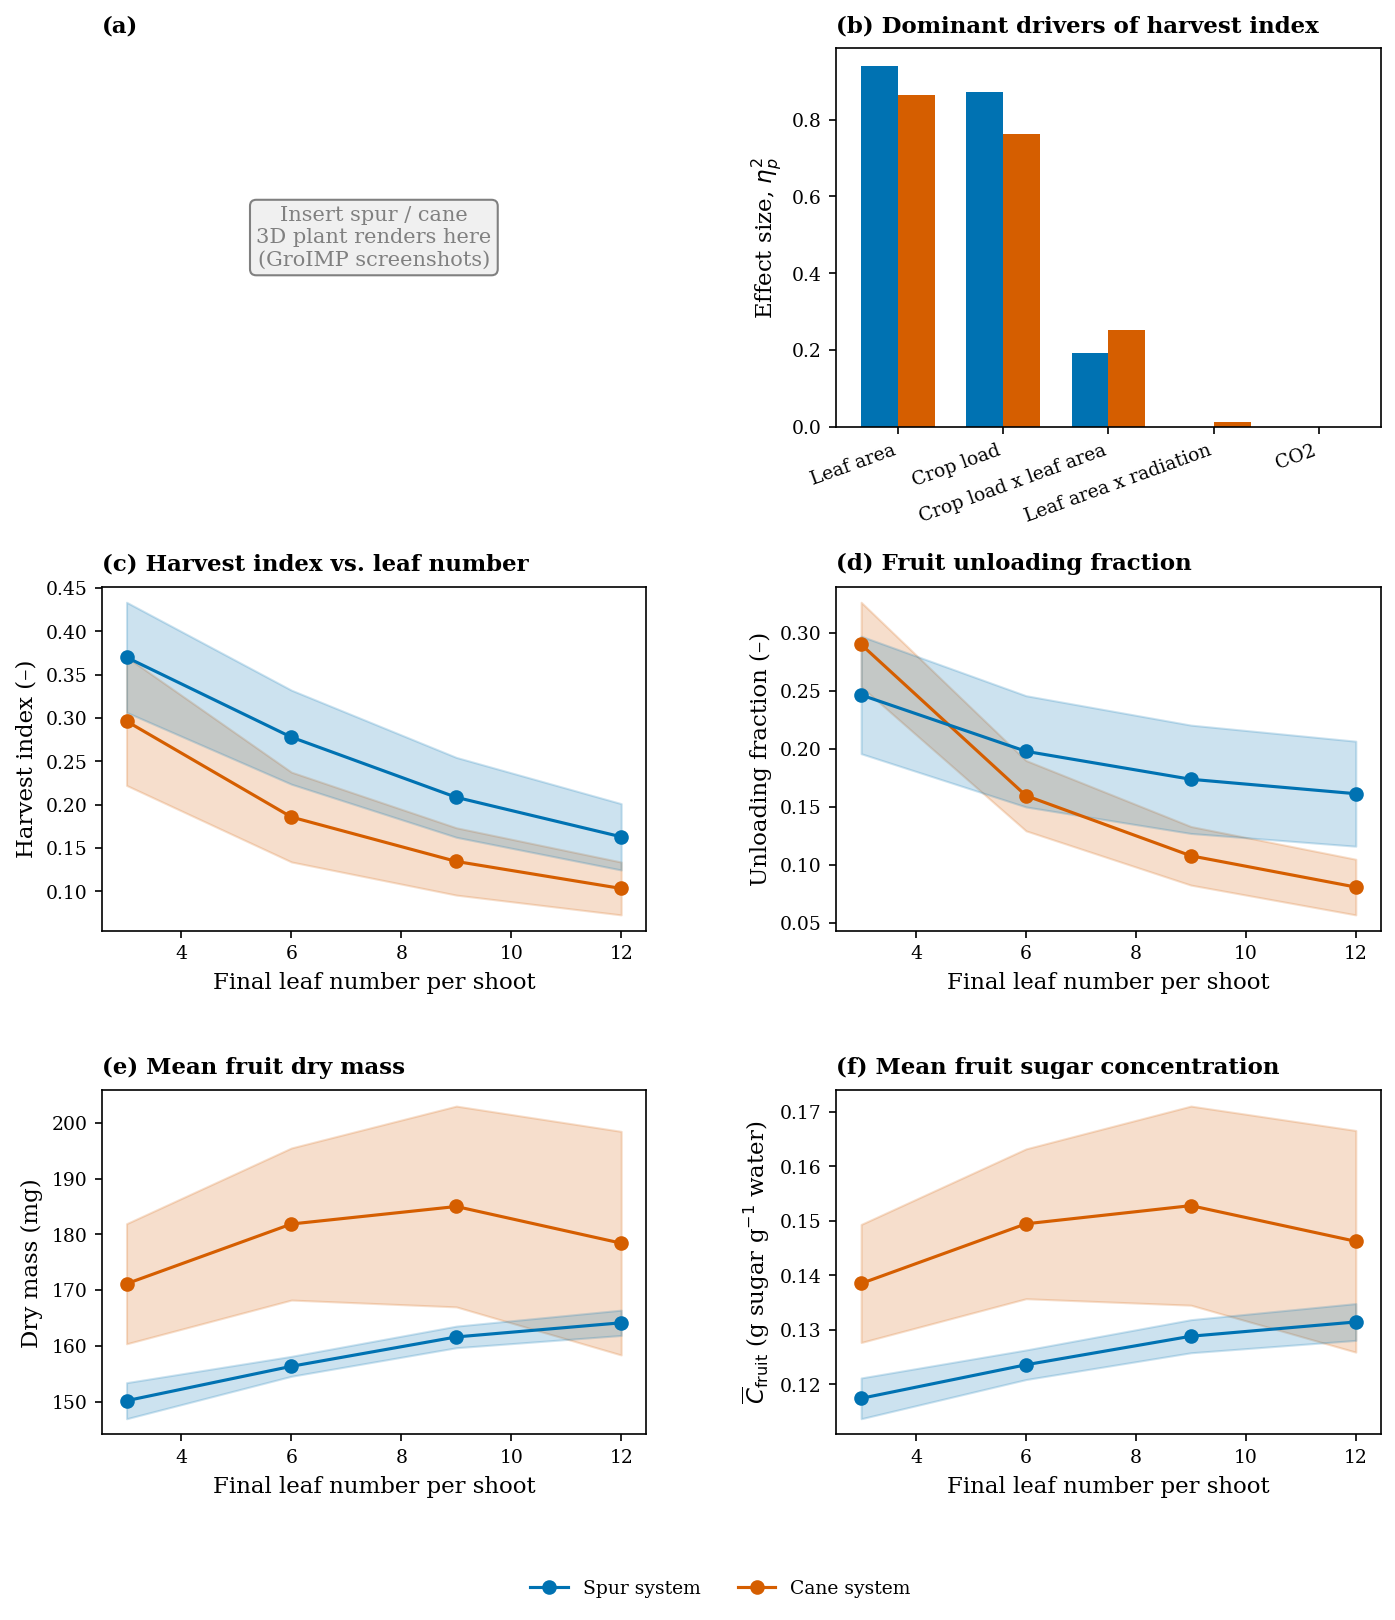

In [16]:
spur_anova = pd.read_csv("outdir/spur/f_values_sensitivity_analysis_results_with_inputs.csv")
cane_anova = pd.read_csv("outdir/cane/f_values_sensitivity_analysis_results_with_inputs.csv")

spur_summary = pd.read_csv("outdir/spur/per_simulation_df_with_treatment.csv")
cane_summary = pd.read_csv("outdir/cane/per_simulation_df_with_treatment.csv")
all_summary = pd.concat([spur_summary, cane_summary], ignore_index=True)

colors = {"spur": "#0072B2", "cane": "#D55E00"} 

fig = plt.figure(figsize=(11, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.45, wspace=0.35)

ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1])
ax_C = fig.add_subplot(gs[1, 0])
ax_D = fig.add_subplot(gs[1, 1])
ax_E = fig.add_subplot(gs[2, 0])
ax_F = fig.add_subplot(gs[2, 1])


# Panel B: dominant drivers of harvest index (effect size, partial eta^2)
factor_map = {
    "leafArea": "Leaf area",
    "totalFruitNumber": "Crop load",
    "totalFruitNumber:leafArea": "Crop load x leaf area",
    "leafArea:incomingRadiation": "Leaf area x radiation",
    "cca": "CO2",
}

def get_eta(df, factor):
    row = df[(df["Target"] == "harvest_index") & (df["index"] == factor)]
    return row["Partial_Eta2"].values[0] if len(row) else 0.0

factors = list(factor_map.keys())
factor_labels = list(factor_map.values())
spur_vals = [get_eta(spur_anova, f) for f in factors]
cane_vals = [get_eta(cane_anova, f) for f in factors]

x = np.arange(len(factors))
width = 0.35

ax_A.axis("off")
ax_A.text(0.5, 0.5, "Insert spur / cane\n3D plant renders here\n(GroIMP screenshots)",
           ha='center', va='center', fontsize=10, color='gray',
           bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))
ax_A.set_title("(a)", loc="left", fontweight="bold", pad=8)

ax_B.bar(x - width/2, spur_vals, width, label="Spur system", color=colors["spur"])
ax_B.bar(x + width/2, cane_vals, width, label="Cane system", color=colors["cane"])
ax_B.set_xticks(x)
ax_B.set_xticklabels(factor_labels, rotation=20, ha='right')
ax_B.set_ylabel(r"Effect size, $\eta_p^2$")
ax_B.set_title("(b) Dominant drivers of harvest index", loc="left", fontweight="bold", pad=8)

# Panels C-F: treatment-mean line plots vs leaf number
line_specs = [
    (ax_C, 'c', 'harvest_index', 'Harvest index (\u2013)', 'Harvest index vs. leaf number'),
    (ax_D, 'd', 'fraction_fruitUnloading', 'Unloading fraction (\u2013)', 'Fruit unloading fraction'),
    (ax_E, 'e', 'meanFruitDW', 'Dry mass (mg)', 'Mean fruit dry mass'),
    (ax_F, 'f', 'meanFruitSc', r"$\overline{C}_{\mathrm{fruit}}$ (g sugar g$^{-1}$ water)", 'Mean fruit sugar concentration'),
]

for ax, letter, col, ylabel, title in line_specs:
    for vt, sub in all_summary.groupby("vineType"):
        means = sub.groupby("ENDING_LEAF_NUMBER")[col].mean()
        stds = sub.groupby("ENDING_LEAF_NUMBER")[col].std()
        ax.plot(means.index, means.values, marker='o', color=colors[vt],
                label=f"{vt.capitalize()} system")
        ax.fill_between(means.index, means.values - stds.values, means.values + stds.values,
                         color=colors[vt], alpha=0.2)
    ax.set_xlabel("Final leaf number per shoot")
    ax.set_ylabel(ylabel)
    ax.set_title(f"({letter}) {title}", loc="left", fontweight="bold", pad=8)

# Shared legend, built after the loop so ax_C actually has plotted data on it
plotted_handles, plotted_labels = ax_C.get_legend_handles_labels()
handle_by_label = dict(zip(plotted_labels, plotted_handles))
legend_labels = ["Spur system", "Cane system"]
legend_handles = [handle_by_label[l] for l in legend_labels]
fig.legend(legend_handles, legend_labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01), frameon=False)

fig.savefig("outdir/Figure6.png", dpi=300, bbox_inches="tight")
fig.savefig("outdir/Figure6.pdf", bbox_inches="tight")
plt.show()

### Figure 6. Harvest-index sensitivity in controlled-environment grapevine simulations comparing spur- and cane-trained systems. (a) Representative three-dimensional canopy renderings of the spur (left) and cane (right) training systems. (b) Top five inputs ranked by ANOVA effect size (η²) explaining variation in harvest index, for spur (blue) and cane (orange). (c-f) Response of (c) harvest index, (d) fraction of carbon unloaded to fruit, (e) mean fruit dry weight, and (f) fruit soluble sugar concentration to final leaf number per shoot (3, 6, 9, 12), for spur and cane. Points show the mean, with shaded bands showing mean ± 1 SD across retained treatment combinations of CO₂ concentration (400-1200 ppm), incoming radiation (400-1200 μmol m⁻² s⁻¹), and day/night temperature (25/15 °C and 30/20 °C). The SD reflects variability across sampled treatment combinations, not uncertainty in the estimated mean. Leaf area and crop load are the dominant drivers of harvest index in both systems; increasing leaf number reduces harvest index and the fruit-unloading fraction, while mean fruit dry weight and sugar concentration increase.

In [17]:
print(all_summary.groupby(['vineType', 'ENDING_LEAF_NUMBER'])['harvest_index'].sem())

vineType  ENDING_LEAF_NUMBER
cane      3.0                   0.004700
          6.0                   0.003376
          9.0                   0.002536
          12.0                  0.002030
spur      3.0                   0.004080
          6.0                   0.003448
          9.0                   0.003212
          12.0                  0.002442
Name: harvest_index, dtype: float64


### S1: broader sensitivity analysis

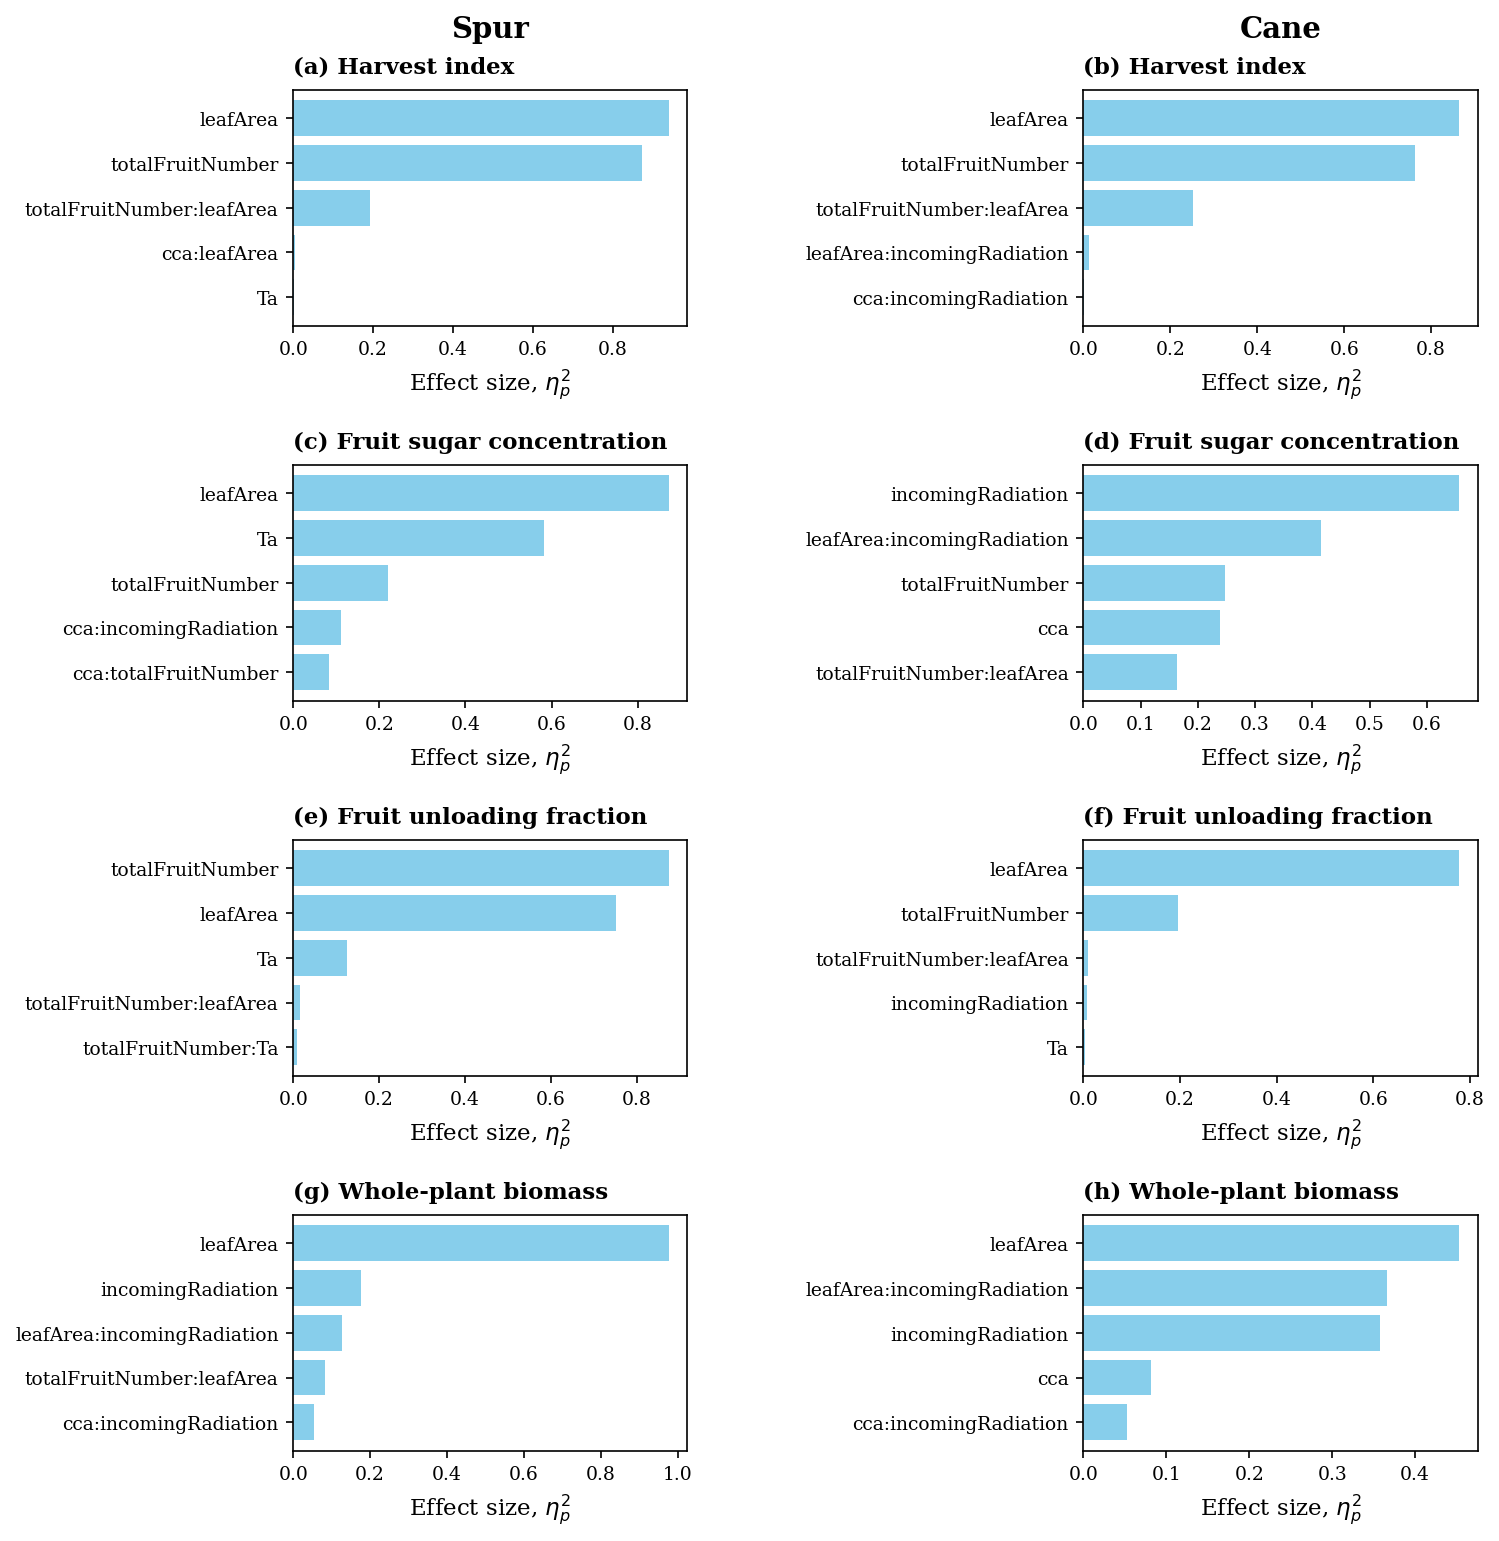

In [18]:
import string
s1_targets = [
    ('harvest_index', 'Harvest index'),
    ('meanFruitSc', 'Fruit sugar concentration'),
    ('fraction_fruitUnloading', 'Fruit unloading fraction'),
    ('biomassPlant', 'Whole-plant biomass'),
]
panel_letters = iter(string.ascii_lowercase)
fig, axes = plt.subplots(4, 2, figsize=(10, 10), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.05, wspace=0.15)

for row, (target, title) in enumerate(s1_targets):
    for col, (anova_df, vine_type) in enumerate([(spur_anova, 'Spur'), (cane_anova, 'Cane')]):
        ax = axes[row, col]
        letter = next(panel_letters)
        top5 = (anova_df[anova_df['Target'] == target]
                .sort_values('Partial_Eta2', ascending=False).head(5))
        ax.barh(top5['index'], top5['Partial_Eta2'], color='skyblue')
        ax.invert_yaxis()
        ax.tick_params(axis='y', labelsize=9)
        ax.set_xlabel(r"Effect size, $\eta_p^2$")
        ax.set_title(f"({letter}) {title}", loc="left", fontweight="bold", fontsize=11, pad=8)

fig.canvas.draw()
for col, vine_type in enumerate(['Spur', 'Cane']):
    pos = axes[0, col].get_position()
    x_center = (pos.x0 + pos.x1) / 2
    fig.text(x_center, pos.y1 + 0.035, vine_type, ha='center', fontsize=14, fontweight='bold')

fig.savefig("outdir/FigureS1.pdf", bbox_inches="tight")
fig.savefig("outdir/FigureS1.png", dpi=300, bbox_inches="tight")
plt.show()

### Supplementary Figure S1. Broader sensitivity analysis of key model outputs in spur (left column) and cane (right column) systems. Each row shows the top five inputs, ranked by ANOVA effect size (η²), explaining variation in: harvest index (a,b); fruit soluble sugar concentration (c,d); fruit unloading fraction (e,f); and whole-plant biomass (g,h). Leaf area dominates most outputs, while crop load and its interaction with leaf area become comparatively more important for allocation-related variables.

## S2: seasonal dynamics

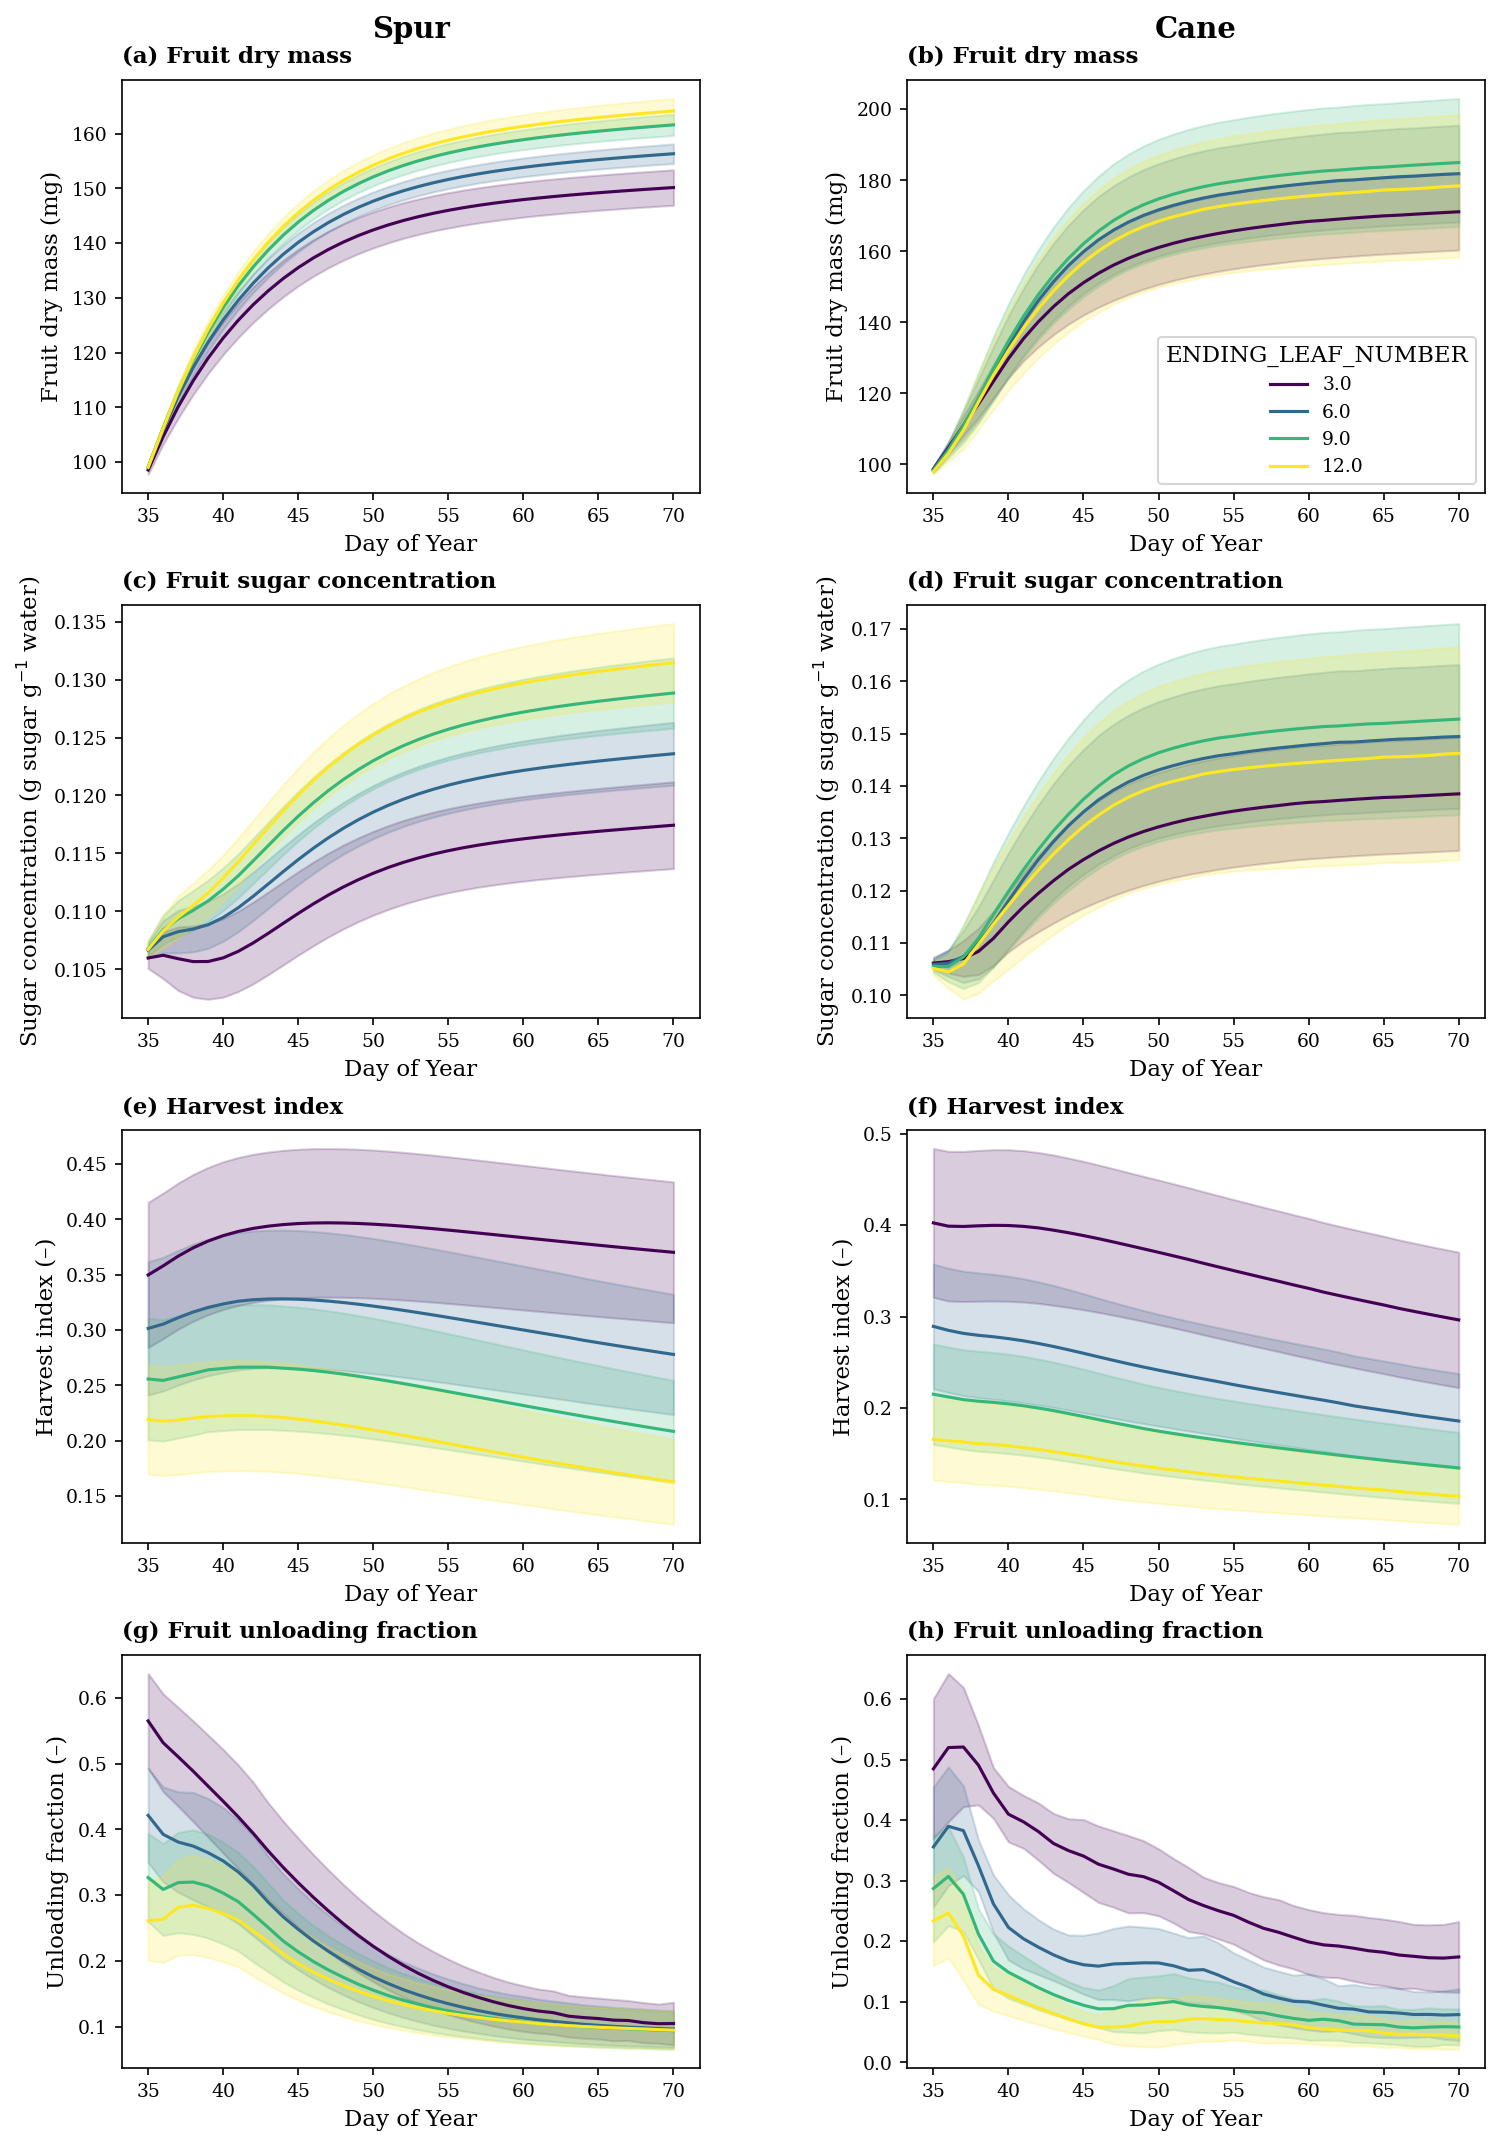

In [19]:
import seaborn as sns

spur_daily = pd.read_csv("/workspace/hrayzl/grapevine-indoor-optimisation/notebooks/models/grapevine/outdir/spur/daily_timeseries_with_treatment.csv")
cane_daily = pd.read_csv("/workspace/hrayzl/grapevine-indoor-optimisation/notebooks/models/grapevine/outdir/cane/daily_timeseries_with_treatment.csv",
        dtype={"baseScenarioFile": "string"},  # avoids DtypeWarning: NaN for reconstructed cane_40/50 rows
    )
all_daily = pd.concat([spur_daily, cane_daily], ignore_index=True)

s2_metrics = [
    ('meanFruitDW', 'Fruit dry mass (mg)', 'Fruit dry mass'),
    ('meanFruitSc', 'Sugar concentration (g sugar g$^{-1}$ water)', 'Fruit sugar concentration'),
    ('harvest_index', 'Harvest index (\u2013)', 'Harvest index'),
    ('fraction_fruitUnloading', 'Unloading fraction (\u2013)', 'Fruit unloading fraction'),
]
panel_letters = iter(string.ascii_lowercase)
fig, axes = plt.subplots(4, 2, figsize=(10, 14), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.05, hspace=0.02, wspace=0.15)

for row, (col_name, ylabel, title_text) in enumerate(s2_metrics):
    for col, vine_type in enumerate(['spur', 'cane']):
        ax = axes[row, col]
        letter = next(panel_letters)
        sub = all_daily[all_daily['vineType'] == vine_type]
        sns.lineplot(data=sub, x='dayOfYear', y=col_name, hue='ENDING_LEAF_NUMBER',
             palette='viridis', ax=ax, legend=(row == 0 and col == 1), errorbar='sd')
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Day of Year")
        ax.set_title(f"({letter}) {title_text}", loc="left", fontweight="bold", fontsize=11, pad=8)

fig.canvas.draw()
for col, vine_type in enumerate(['Spur', 'Cane']):
    pos = axes[0, col].get_position()
    x_center = (pos.x0 + pos.x1) / 2
    fig.text(x_center, pos.y1 + 0.02, vine_type, ha='center', fontsize=14, fontweight='bold')

fig.savefig("outdir/FigureS2.pdf", bbox_inches="tight")
fig.savefig("outdir/FigureS2.png", dpi=300, bbox_inches="tight")
plt.show()

### Supplementary Figure S2. Seasonal source-sink dynamics across the four final-leaf-number treatments (3, 6, 9, 12 leaves per shoot) in spur (left column) and cane (right column) systems. Panels show daily trajectories of fruit dry weight (a,b), fruit sugar concentration (c,d), harvest index (e,f), and fruit unloading fraction (g,h). Colour indicates final leaf number (3-12); shaded bands show mean ± 1 SD across retained treatment combinations. These trajectories show that the main-figure endpoint differences arise from cumulative divergence over the season rather than a single final-day effect.

### S3: leaf number x crop-load response surface

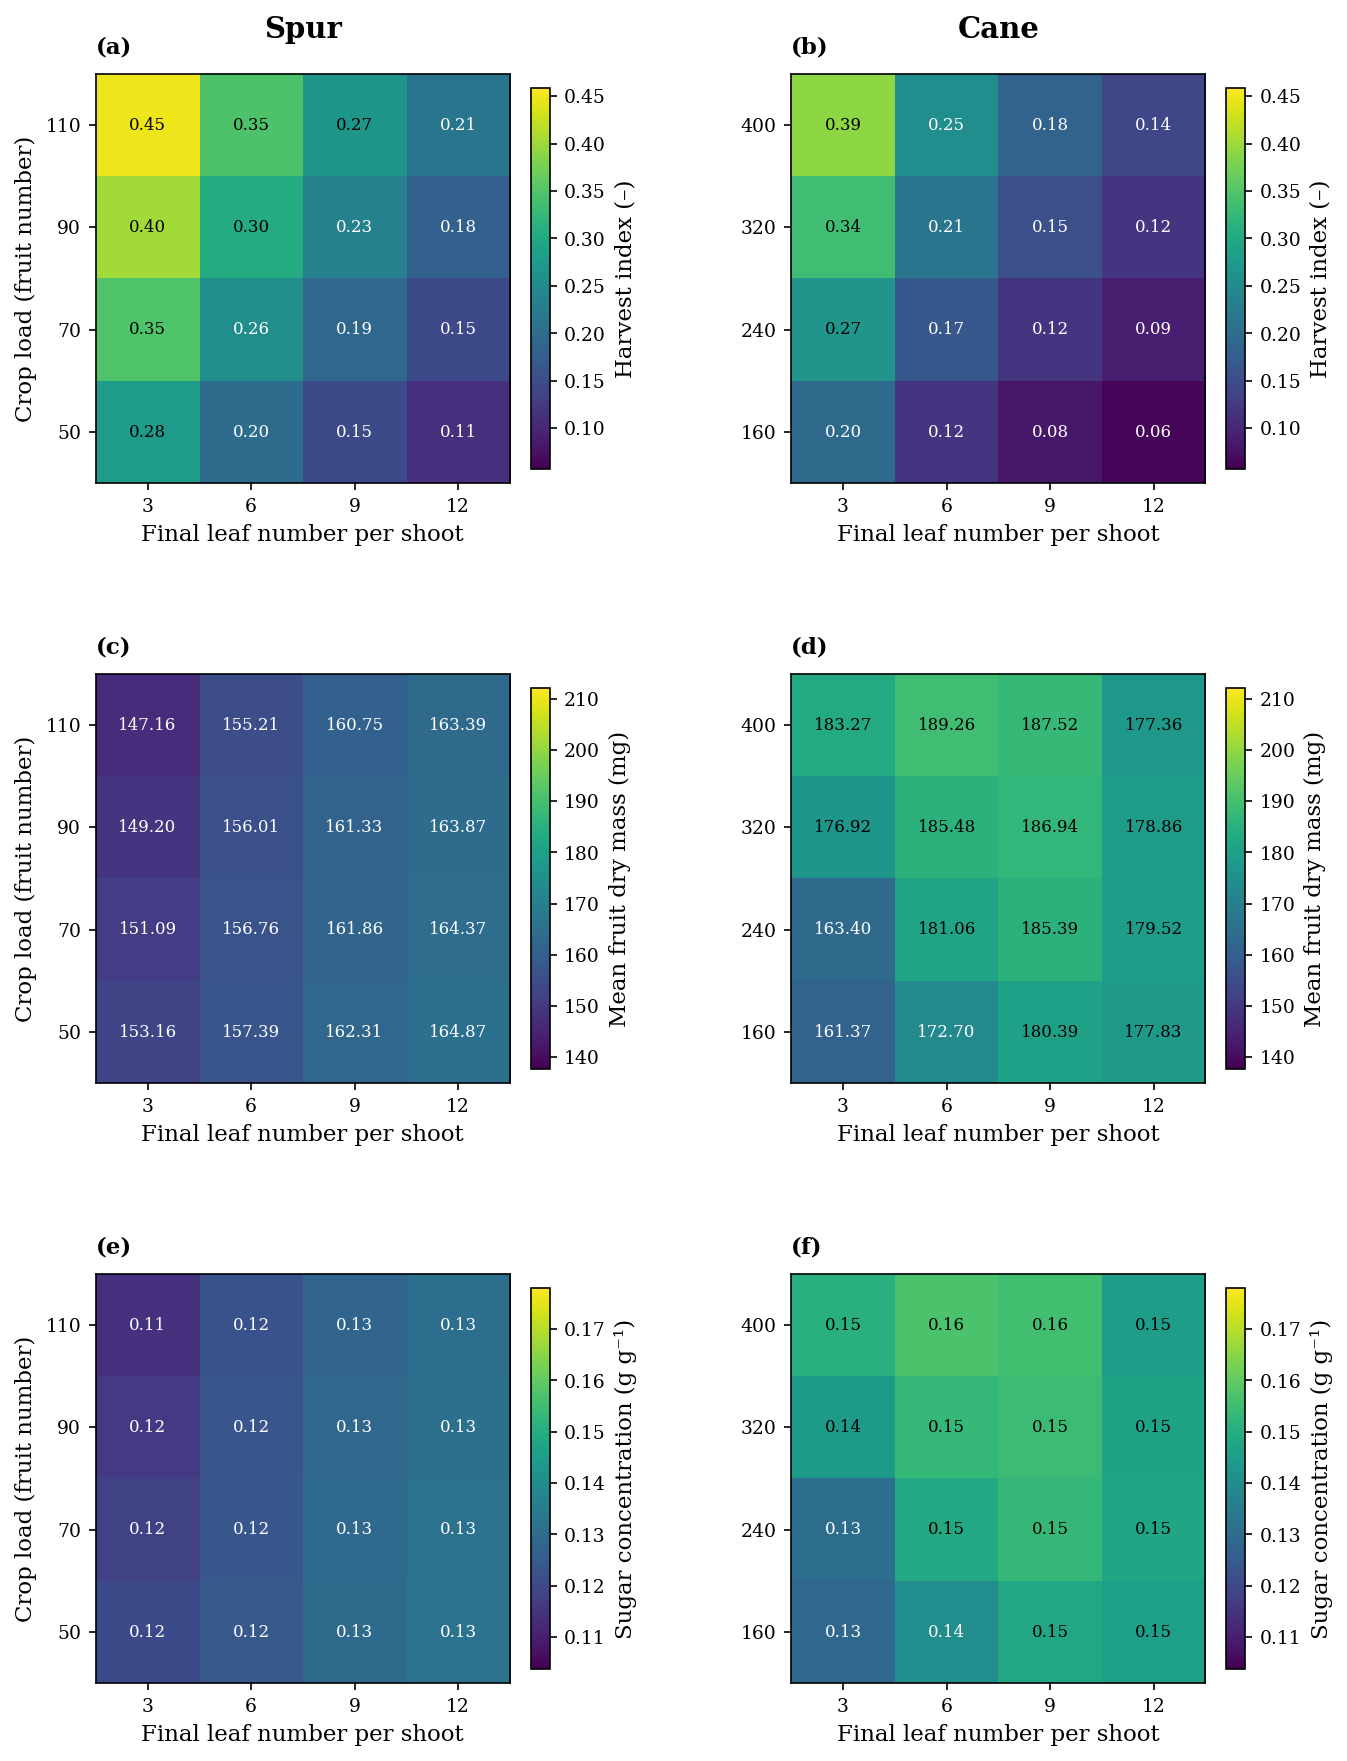

In [23]:
s3_targets = [
    ('harvest_index', 'Harvest index (\u2013)'),
    ('meanFruitDW', 'Mean fruit dry mass (mg)'),
    ('meanFruitSc', 'Sugar concentration (g g\u207b\u00b9)'),
]
fig, axes = plt.subplots(3, 2, figsize=(9, 12), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.3, hspace=0.008, wspace=0.15)
panel_letters = iter(string.ascii_lowercase)

for row, (target, title) in enumerate(s3_targets):
    vmin = min(spur_summary[target].min(), cane_summary[target].min())
    vmax = max(spur_summary[target].max(), cane_summary[target].max())
    for col, (summary_df, vine_type) in enumerate([(spur_summary, 'Spur'), (cane_summary, 'Cane')]):
        ax = axes[row, col]
        letter = next(panel_letters)
        pivot = summary_df.pivot_table(index='totalFruitNumber', columns='ENDING_LEAF_NUMBER',
                                        values=target, aggfunc='mean')
        im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', origin='lower',
                        vmin=vmin, vmax=vmax)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                normalized = (val - vmin) / (vmax - vmin)
                ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                        color='white' if normalized < 0.5 else 'black', fontsize=8)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns.astype(int))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index.astype(int))
        ax.set_xlabel("Final leaf number per shoot")
        if col == 0:
            ax.set_ylabel("Crop load (fruit number)")
        # vine_type moved to a column header above; each panel title is just its letter
        ax.set_title(f"({letter})", loc="left", fontweight="bold", fontsize=11, pad=10)
        fig.colorbar(im, ax=ax, fraction=0.046, label=title)

# Column headers, "Spur" / "Cane", placed above the top row
fig.canvas.draw()
for col, vine_type in enumerate(['Spur', 'Cane']):
    pos = axes[0, col].get_position()
    x_center = (pos.x0 + pos.x1) / 2
    fig.text(x_center, pos.y1 + 0.02, vine_type, ha='center', fontsize=14, fontweight='bold')

fig.savefig("outdir/FigureS3.pdf", bbox_inches="tight")
fig.savefig("outdir/FigureS3.png", dpi=300, bbox_inches="tight")
plt.show()

### Supplementary Figure S3. Leaf number x crop-load response surfaces for spur (left column) and cane (right column) systems. Heatmaps show harvest index (a,b), mean fruit dry matter (c,d), and fruit soluble sugar concentration (e,f) across all combinations of final leaf number and crop load. Colour scale is shared between spur and cane within each row for direct comparison. Note the crop-load range differs between systems (50-110 fruit for spur, 160-400 fruit for cane), reflecting the different baseline fruit loads of the two training systems. These surfaces illustrate the leaf-area x crop-load interaction identified in the sensitivity analysis (Fig. S1).

In [21]:
cane_check = pd.read_csv("outdir/cane/per_simulation_df_with_treatment.csv")
print(cane_check['meanFruitDW'].describe())

count    946.000000
mean     178.992115
std       16.743023
min      137.700798
25%      164.881990
50%      180.104780
75%      192.328667
max      212.126636
Name: meanFruitDW, dtype: float64


In [22]:
print(all_summary.groupby(['vineType', 'ENDING_LEAF_NUMBER'])['harvest_index'].agg(['count', 'std', 'sem']))

                             count       std       sem
vineType ENDING_LEAF_NUMBER                           
cane     3.0                   249  0.074166  0.004700
         6.0                   236  0.051863  0.003376
         9.0                   235  0.038876  0.002536
         12.0                  226  0.030524  0.002030
spur     3.0                   243  0.063601  0.004080
         6.0                   248  0.054306  0.003448
         9.0                   206  0.046106  0.003212
         12.0                  246  0.038307  0.002442
